# Demonstration of symmetry-exploiting SVD in Panther-EM.

1. Download and simulate cryo-EM projections of a structure
2. Perform optimized SVD decomposition by exploiting in-plane rotational symmetry (in polar coordinates)
3. Plot singular values of the decomposition
4. Plot polar/cartesian features of decomposition

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch_so3 import get_uniform_euler_angles

from panther_em.decomposition import PolarProjectionDecomposer
from panther_em.inference.projection_reconstruction import ProjectionReconstructor
from panther_em.coordinates import OffsetPolarTransform

## Constants for the notebook

Change device variable depending on hardware availability (e.g. `"cpu"` if CPU only).

In [3]:
DEVICE = torch.device("cuda:1")

## Load in volume to take projections from

In [4]:
!wget -nc https://files.rcsb.org/download/pdb_00001dpo.cif

File ‘pdb_00001dpo.cif’ already there; not retrieving.



In [5]:
from simulate_volume import simulate_volume

In [6]:
volume = simulate_volume(
    pdb_path="pdb_00001dpo.cif",
    pixel_spacing=0.4,
    volume_shape=(256, 256, 256),
    voltage=300.0,
    dose_start=0.0,
    dose_end=15.0,
    b_factor_scaling=1.0,
    additional_b_factor=30.0,
)

In [7]:
type(volume), volume.shape, volume.dtype

(numpy.ndarray, (256, 256, 256), dtype('float32'))

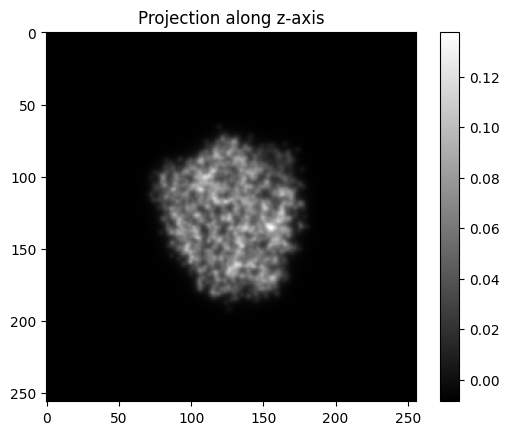

In [8]:
plt.imshow(volume.sum(axis=0), cmap="gray")
plt.title("Projection along z-axis")
plt.colorbar()
plt.show()

## Define the out-of-plane orientations

Using `torch-so3` to approximate points over SO(3) space, except all in-plane angles are set to zero.

In [9]:
angles = get_uniform_euler_angles(psi_step=360.0, theta_step=6.0)
print(angles.shape)

phi_angles = angles[:, 0].numpy()
theta_angles = angles[:, 1].numpy()

torch.Size([1148, 3])


## Run the decomposition

In [10]:
radial_components = 256
angular_components = 360

transformer = OffsetPolarTransform.from_image(
    image_shape=volume.shape[1:],
    num_angle=angular_components,
    num_radius=radial_components,
    # device=DEVICE,
)

In [11]:
k_max = angular_components // 2
eig_max = 128


decomposer = PolarProjectionDecomposer(
    volume=volume,
    phi_values=phi_angles,
    theta_values=theta_angles,
    coordinate_transform=transformer,
    device=DEVICE,
)

result = decomposer.do_decomposition(k_max=k_max, eig_max=eig_max)

decomp freq blocks: 100%|██████████| 23/23 [00:02<00:00, 11.04it/s]


In [11]:
result

DecompositionResult(
    k_max=180,
    eig_max=128,
    is_complex_projection=False,
    num_fourier_filters=1,
    num_orientations=1148,
    num_angular_components=360,
    num_radial_components=256,
    has_euler_angles=True,
    has_fourier_filters=False,
    coordinate_transform='grid',
    created_at='2026-06-01T14:51:34.849986'
)

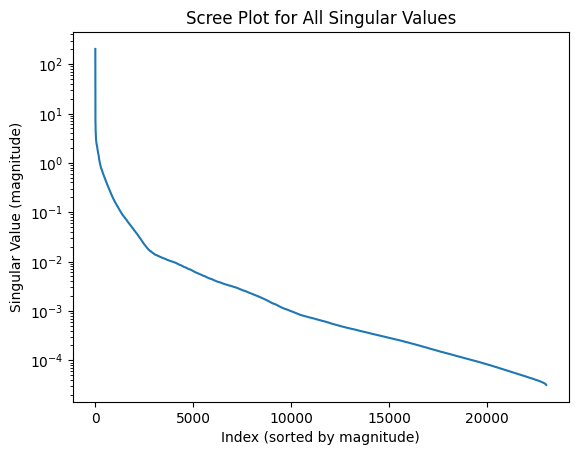

In [12]:
fix, ax = result.scree_plot()
plt.yscale("log")

## Visualize real/imag feature components in polar and cartesian space

In [13]:
reconstructor = ProjectionReconstructor(result=result, device=DEVICE)

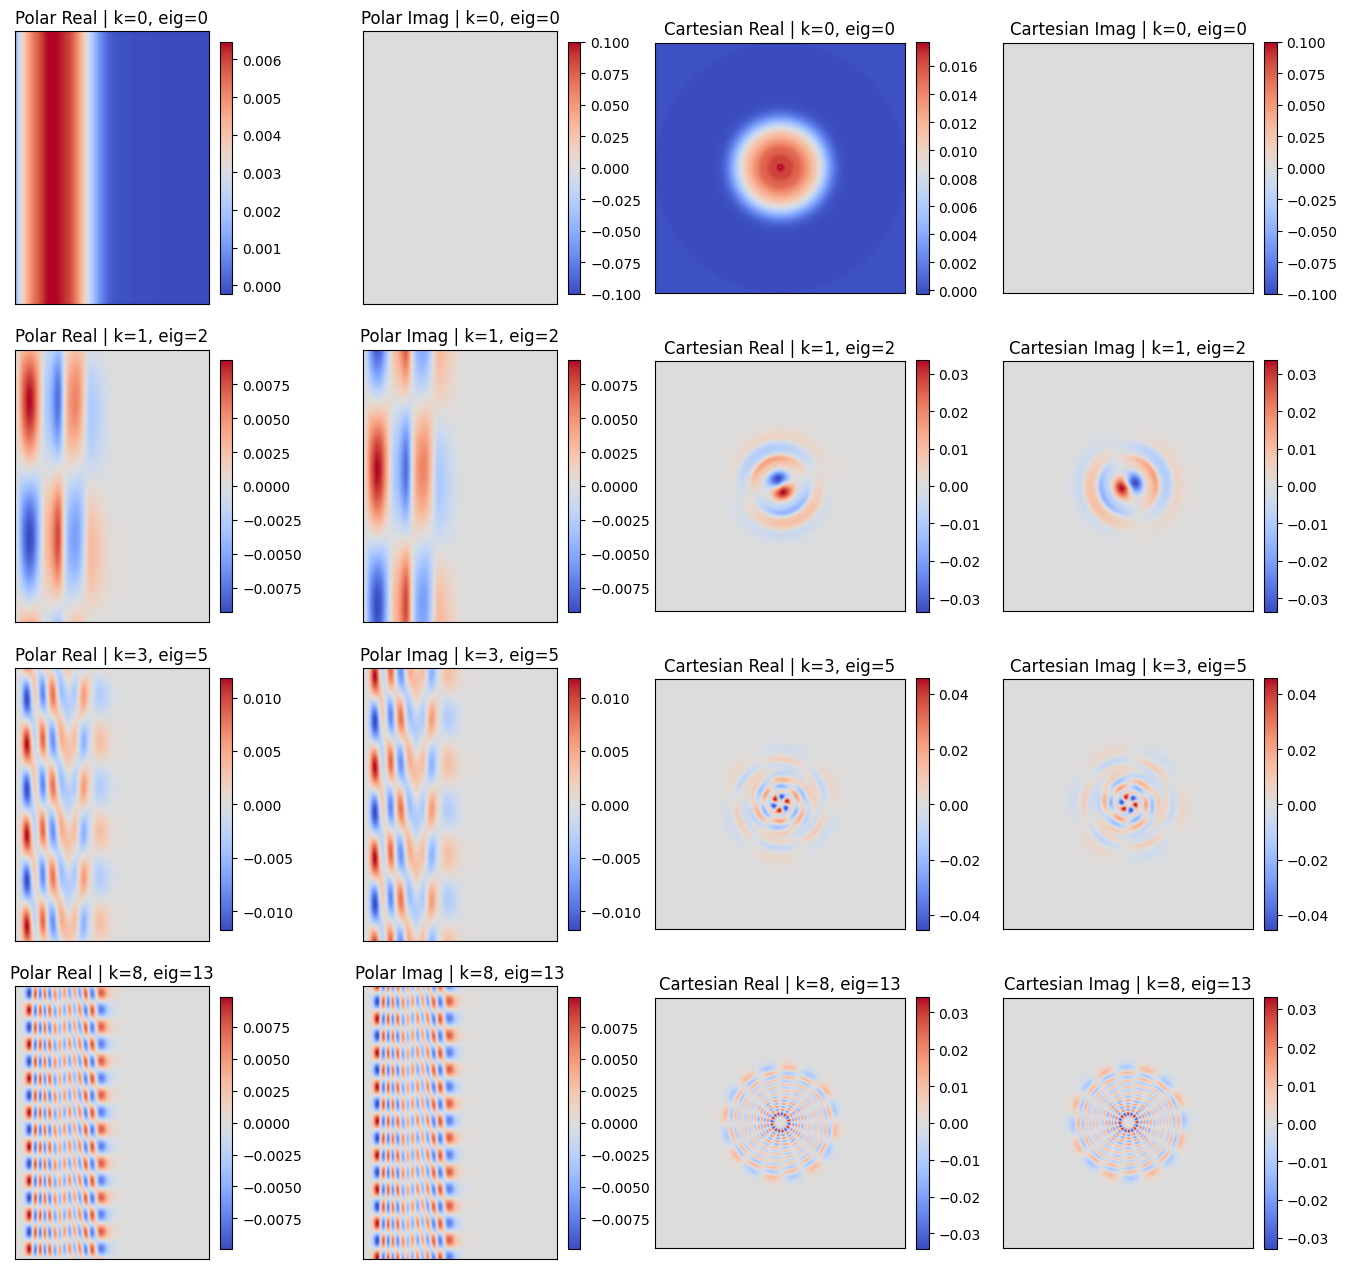

In [14]:
# Pick a few (k_idx, eig_idx) feature pairs to inspect
feature_pairs = [(0, 0), (1, 2), (3, 5), (8, 13)]

n = len(feature_pairs)
fig, axes = plt.subplots(n, 4, figsize=(14, 3.2 * n), squeeze=False)

for row, (k_idx, eig_idx) in enumerate(feature_pairs):
    polar_feature = reconstructor.construct_polar_feature(k_idx=k_idx, eig_idx=eig_idx)
    cart_feature = reconstructor.construct_cartesian_feature(
        k_idx=k_idx, eig_idx=eig_idx
    )

    panels = [
        (np.real(polar_feature), "Polar Real"),
        (np.imag(polar_feature), "Polar Imag"),
        (np.real(cart_feature), "Cartesian Real"),
        (np.imag(cart_feature), "Cartesian Imag"),
    ]

    for col, (img, title) in enumerate(panels):
        ax = axes[row, col]
        im = ax.imshow(img, cmap="coolwarm")
        ax.set_title(f"{title} | k={k_idx}, eig={eig_idx}")
        ax.set_xticks([])
        ax.set_yticks([])
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

## Projection reconstructions up to a certain rank

In [15]:
ranks = [4, 16, 64, 256, 1024, 4096]
reconstructions = []

for r in ranks:
    recon = reconstructor.reconstruct_projection(
        orientation_idx=0,
        fourier_filter_idx=0,
        in_plane_rotation=20,
        num_components=r,
        return_polar=False,
        return_torch=False,
    )
    reconstructions.append(recon)

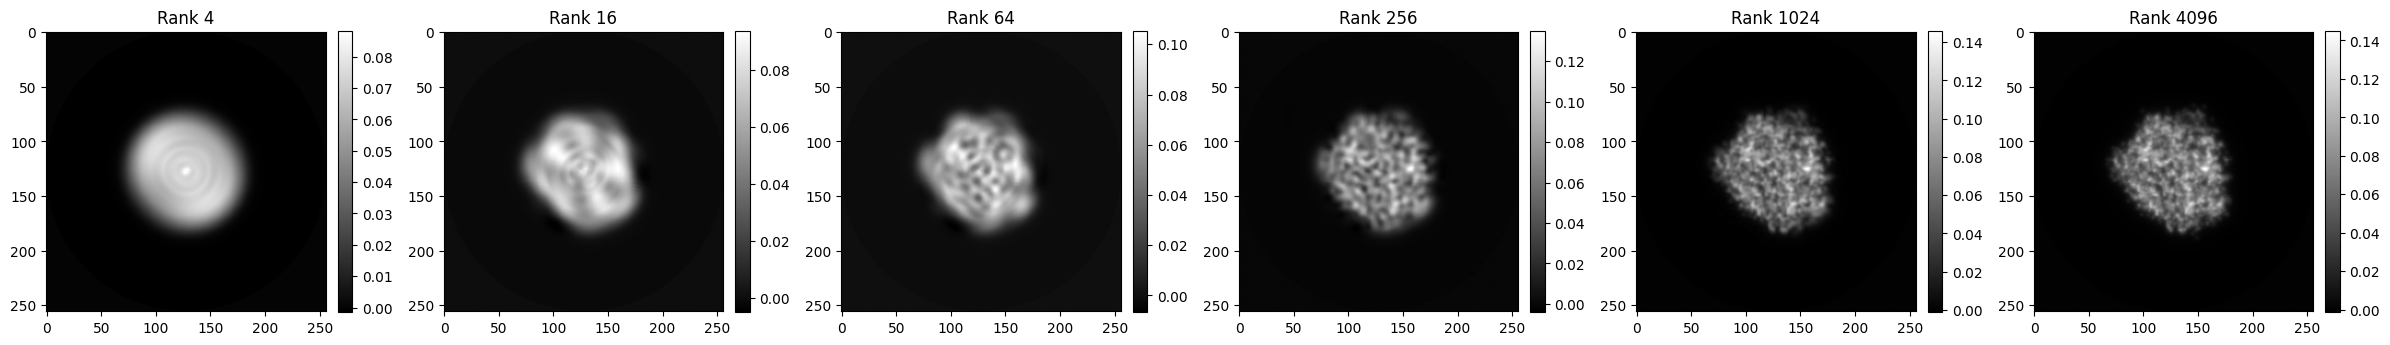

In [16]:
# Plot the reconstructions
fig, axes = plt.subplots(1, len(ranks), figsize=(4 * len(ranks), 4))

for ax, recon, r in zip(axes, reconstructions, ranks, strict=False):
    im = ax.imshow(recon.real, cmap="gray")
    ax.set_title(f"Rank {r}")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [17]:
print("left-singular-vectors shape:                  ", result.U.shape)
print("singular-values shape:                        ", result.S.shape)
print("right-singular-vectors (conj transpose) shape:", result.Vh.shape)

left-singular-vectors shape:                   (1, 1148, 180, 128)
singular-values shape:                         (180, 128)
right-singular-vectors (conj transpose) shape: (180, 128, 256)
